# 第10章: 検定の基礎と検定法の導出

## 学習目標
- 帰無仮説と対立仮説を理解する
- 第一種の誤りと第二種の誤りを理解する
- 検出力関数を理解し計算できる
- ネイマン・ピアソンの補題を理解する
- 尤度比検定を導出できる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

仮説検定は、データから仮説の妥当性を統計的に判断する手法です。第1種・第2種の誤りを制御しながら、科学的な意思決定を行います。

### 実世界での応用

**新薬の承認**: プラセボと比較して有意差があるか検定

**製造工程の異常検知**: 平均値が基準値から逸脱していないか検定

**マーケティング施策**: 施策前後で売上に有意差があるか検定

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 10.1 仮説検定の基本概念

### 帰無仮説と対立仮説
- **帰無仮説** $H_0$: 棄却したい仮説（通常「効果がない」「差がない」）
- **対立仮説** $H_1$: 採択したい仮説

### 検定の種類
- **両側検定**: $H_0: \theta = \theta_0$ vs $H_1: \theta \neq \theta_0$
- **片側検定**: $H_0: \theta \leq \theta_0$ vs $H_1: \theta > \theta_0$

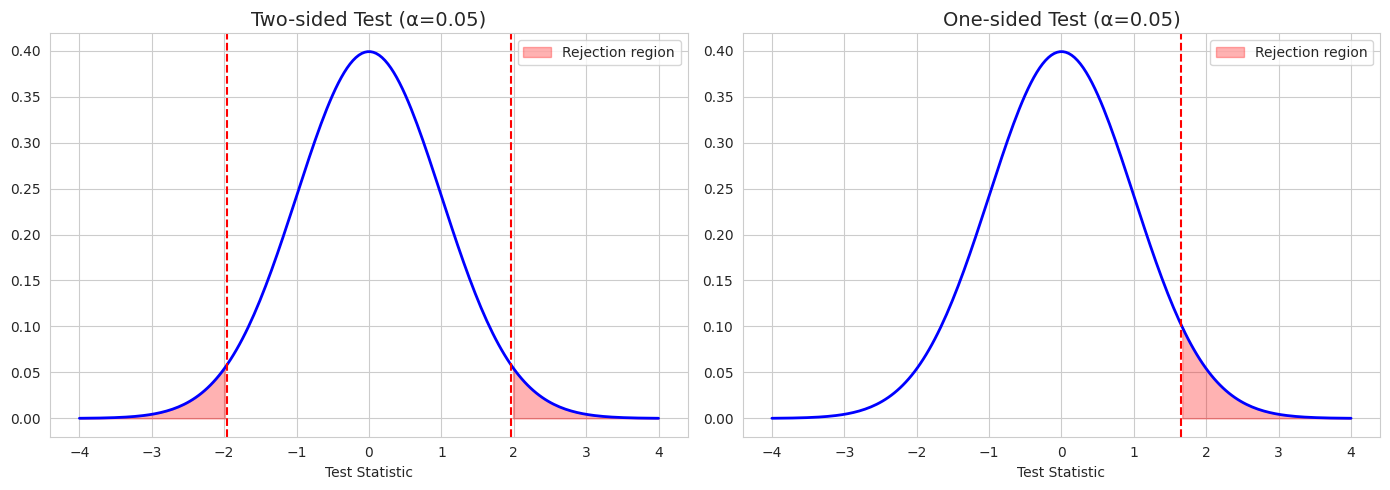

Two-sided critical values: ±1.960
One-sided critical value: 1.645


In [2]:
# 検定の概念の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-4, 4, 200)
alpha = 0.05

# Two-sided test
z_crit = stats.norm.ppf(1 - alpha/2)
axes[0].plot(x, stats.norm.pdf(x), 'b-', linewidth=2)
axes[0].fill_between(x[x < -z_crit], stats.norm.pdf(x[x < -z_crit]), alpha=0.3, color='red', label='Rejection region')
axes[0].fill_between(x[x > z_crit], stats.norm.pdf(x[x > z_crit]), alpha=0.3, color='red')
axes[0].axvline(-z_crit, color='red', linestyle='--')
axes[0].axvline(z_crit, color='red', linestyle='--')
axes[0].set_title(f'Two-sided Test (α={alpha})', fontsize=14)
axes[0].set_xlabel('Test Statistic')
axes[0].legend()

# One-sided test (right)
z_crit_one = stats.norm.ppf(1 - alpha)
axes[1].plot(x, stats.norm.pdf(x), 'b-', linewidth=2)
axes[1].fill_between(x[x > z_crit_one], stats.norm.pdf(x[x > z_crit_one]), alpha=0.3, color='red', label='Rejection region')
axes[1].axvline(z_crit_one, color='red', linestyle='--')
axes[1].set_title(f'One-sided Test (α={alpha})', fontsize=14)
axes[1].set_xlabel('Test Statistic')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Two-sided critical values: ±{z_crit:.3f}")
print(f"One-sided critical value: {z_crit_one:.3f}")

## 10.2 第一種の誤りと第二種の誤り

### 誤りの種類
| | $H_0$ 真 | $H_1$ 真 |
|---|---|---|
| $H_0$ 採択 | 正しい決定 | 第二種の誤り ($\beta$) |
| $H_0$ 棄却 | 第一種の誤り ($\alpha$) | 正しい決定 |

### 定義
- **第一種の誤り** ($\alpha$): $P(\text{H}_0 \text{を棄却} | H_0 \text{が真})$
- **第二種の誤り** ($\beta$): $P(\text{H}_0 \text{を採択} | H_1 \text{が真})$
- **検出力** (Power): $1 - \beta = P(\text{H}_0 \text{を棄却} | H_1 \text{が真})$

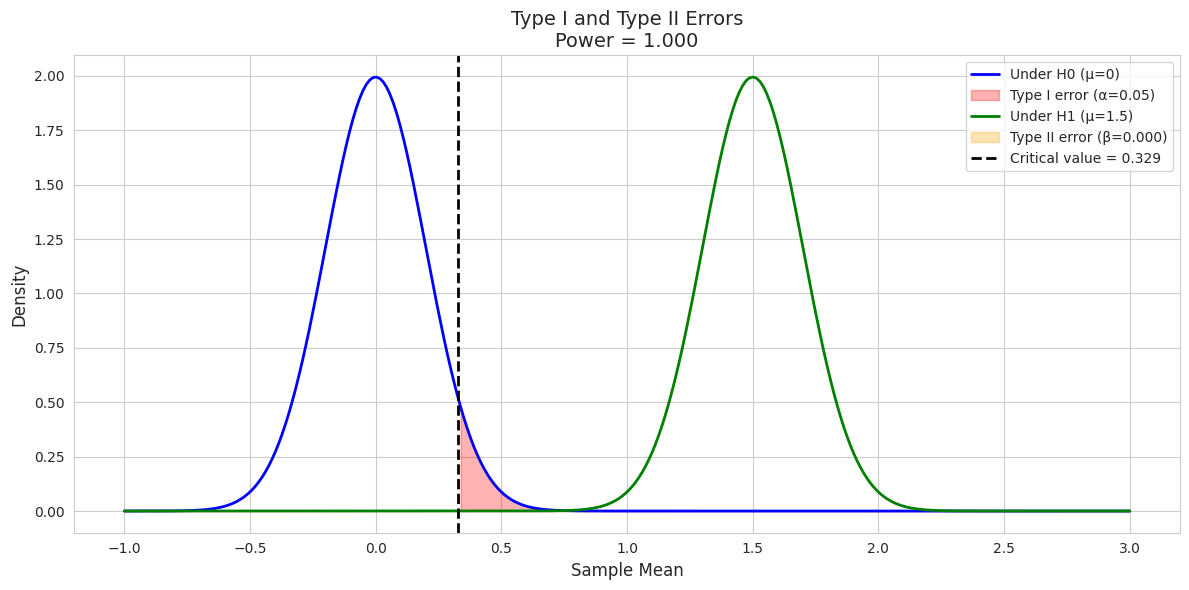

α (Type I error) = 0.05
β (Type II error) = 0.0000
Power = 1 - β = 1.0000


In [3]:
# 第一種・第二種の誤りの可視化
mu_0 = 0  # H0: mu = 0
mu_1 = 1.5  # True mean under H1
sigma = 1
n = 25
alpha = 0.05

# Standard error
se = sigma / np.sqrt(n)

# Critical value
z_crit = stats.norm.ppf(1 - alpha)
critical_value = mu_0 + z_crit * se

# Calculate beta
beta = stats.norm.cdf(critical_value, mu_1, se)
power = 1 - beta

fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(-1, 3, 300)

# Distribution under H0
y0 = stats.norm.pdf(x, mu_0, se)
ax.plot(x, y0, 'b-', linewidth=2, label=f'Under H0 (μ={mu_0})')
ax.fill_between(x[x > critical_value], y0[x > critical_value], alpha=0.3, color='red', label=f'Type I error (α={alpha})')

# Distribution under H1
y1 = stats.norm.pdf(x, mu_1, se)
ax.plot(x, y1, 'g-', linewidth=2, label=f'Under H1 (μ={mu_1})')
ax.fill_between(x[x < critical_value], y1[x < critical_value], alpha=0.3, color='orange', label=f'Type II error (β={beta:.3f})')

ax.axvline(critical_value, color='black', linestyle='--', linewidth=2, label=f'Critical value = {critical_value:.3f}')

ax.set_xlabel('Sample Mean', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Type I and Type II Errors\nPower = {power:.3f}', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"α (Type I error) = {alpha}")
print(f"β (Type II error) = {beta:.4f}")
print(f"Power = 1 - β = {power:.4f}")

## 10.3 検出力関数

### 定義
検出力関数は帰無仮説を棄却する確率をパラメータの関数として表したもの:
$$\pi(\theta) = P_\theta(\text{H}_0 \text{を棄却})$$

### 性質
- $\pi(\theta_0) = \alpha$ (帰無仮説の下での棄却確率)
- $H_1$ の下で $\pi(\theta)$ が大きいほど良い検定

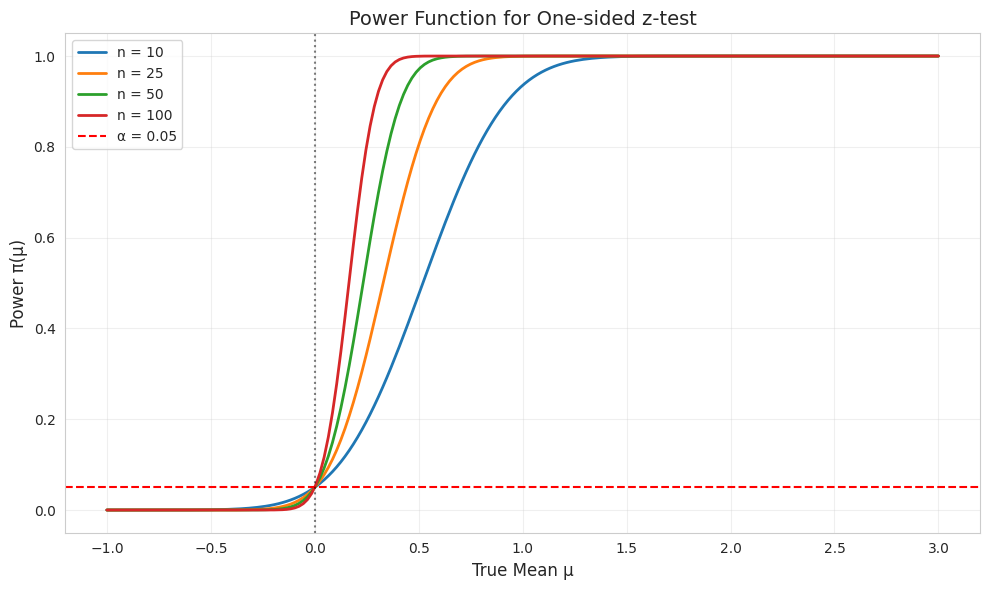

In [4]:
# 検出力関数の可視化
mu_0 = 0
sigma = 1
alpha = 0.05

sample_sizes = [10, 25, 50, 100]
mu_range = np.linspace(-1, 3, 200)

fig, ax = plt.subplots(figsize=(10, 6))

for n in sample_sizes:
    se = sigma / np.sqrt(n)
    z_crit = stats.norm.ppf(1 - alpha)
    critical_value = mu_0 + z_crit * se
    
    # Power function
    power = 1 - stats.norm.cdf(critical_value, mu_range, se)
    ax.plot(mu_range, power, linewidth=2, label=f'n = {n}')

ax.axhline(alpha, color='red', linestyle='--', label=f'α = {alpha}')
ax.axvline(mu_0, color='black', linestyle=':', alpha=0.5)

ax.set_xlabel('True Mean μ', fontsize=12)
ax.set_ylabel('Power π(μ)', fontsize=12)
ax.set_title('Power Function for One-sided z-test', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

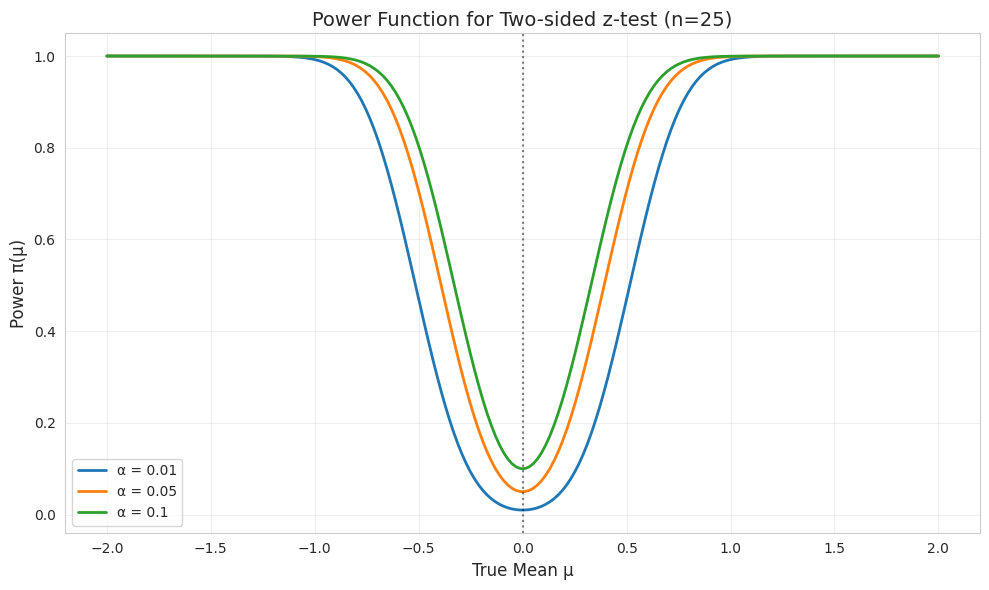

In [5]:
# 両側検定の検出力関数
mu_0 = 0
sigma = 1
n = 25
se = sigma / np.sqrt(n)

alphas = [0.01, 0.05, 0.10]
mu_range = np.linspace(-2, 2, 200)

fig, ax = plt.subplots(figsize=(10, 6))

for alpha in alphas:
    z_crit = stats.norm.ppf(1 - alpha/2)
    lower_crit = mu_0 - z_crit * se
    upper_crit = mu_0 + z_crit * se
    
    # Power function for two-sided test
    power = (1 - stats.norm.cdf(upper_crit, mu_range, se) + 
             stats.norm.cdf(lower_crit, mu_range, se))
    ax.plot(mu_range, power, linewidth=2, label=f'α = {alpha}')

ax.axvline(mu_0, color='black', linestyle=':', alpha=0.5)

ax.set_xlabel('True Mean μ', fontsize=12)
ax.set_ylabel('Power π(μ)', fontsize=12)
ax.set_title(f'Power Function for Two-sided z-test (n={n})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10.4 ネイマン・ピアソンの補題

### 定理
単純仮説 $H_0: \theta = \theta_0$ vs $H_1: \theta = \theta_1$ の検定において、有意水準 $\alpha$ で最も検出力の高い検定（最強力検定）は尤度比検定:

$$\frac{L(\theta_1)}{L(\theta_0)} > k$$

のとき $H_0$ を棄却する。ここで $k$ は $P_{\theta_0}\left(\frac{L(\theta_1)}{L(\theta_0)} > k\right) = \alpha$ を満たす。

In [6]:
# ネイマン・ピアソンの補題の例：正規分布
# H0: μ = 0 vs H1: μ = 1

mu_0, mu_1 = 0, 1
sigma = 1
n = 10
alpha = 0.05

# Likelihood ratio: L(μ1)/L(μ0) = exp(n(μ1-μ0)x̄/σ² - n(μ1²-μ0²)/(2σ²))
# Taking log: n(μ1-μ0)x̄/σ² - n(μ1²-μ0²)/(2σ²) > log(k)
# This reduces to: x̄ > c for some constant c

# Critical value
se = sigma / np.sqrt(n)
z_crit = stats.norm.ppf(1 - alpha)
c = mu_0 + z_crit * se

print("Neyman-Pearson Lemma Application")
print("="*50)
print(f"\nH0: μ = {mu_0} vs H1: μ = {mu_1}")
print(f"\nLikelihood ratio test reduces to: X̄ > {c:.3f}")
print(f"This is the most powerful test at α = {alpha}")

# Simulation to verify
n_simulations = 10000

# Under H0
samples_h0 = np.random.normal(mu_0, sigma, (n_simulations, n))
means_h0 = np.mean(samples_h0, axis=1)
type1_error = np.mean(means_h0 > c)

# Under H1
samples_h1 = np.random.normal(mu_1, sigma, (n_simulations, n))
means_h1 = np.mean(samples_h1, axis=1)
power_empirical = np.mean(means_h1 > c)

# Theoretical power
power_theoretical = 1 - stats.norm.cdf(c, mu_1, se)

print(f"\nSimulation Results ({n_simulations} trials):")
print(f"Empirical Type I error: {type1_error:.4f}")
print(f"Empirical Power: {power_empirical:.4f}")
print(f"Theoretical Power: {power_theoretical:.4f}")

Neyman-Pearson Lemma Application

H0: μ = 0 vs H1: μ = 1

Likelihood ratio test reduces to: X̄ > 0.520
This is the most powerful test at α = 0.05

Simulation Results (10000 trials):
Empirical Type I error: 0.0522
Empirical Power: 0.9356
Theoretical Power: 0.9354


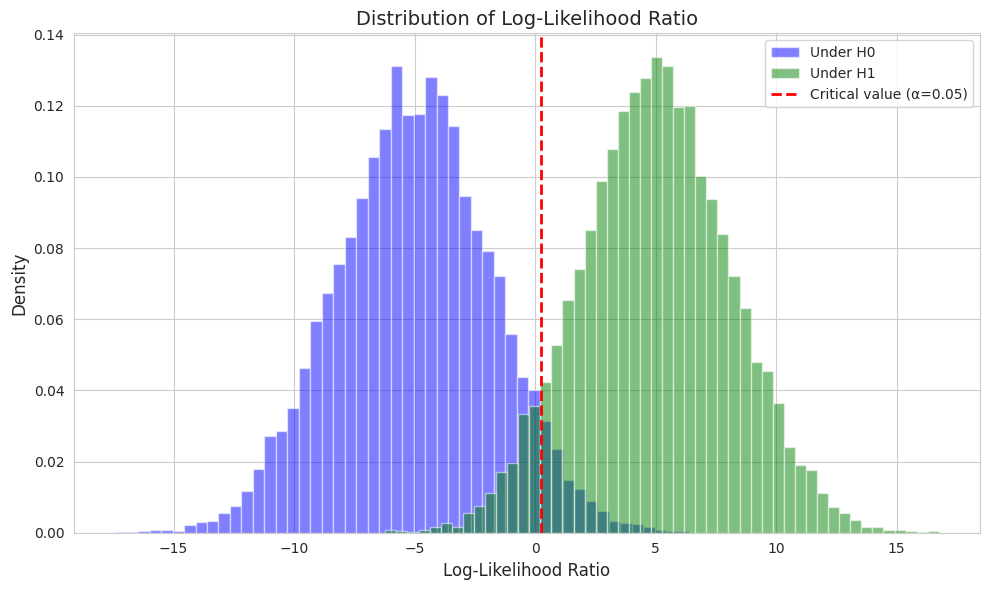

In [7]:
# 尤度比の分布の可視化
mu_0, mu_1 = 0, 1
sigma = 1
n = 10
n_simulations = 10000

# Generate samples under H0 and H1
samples_h0 = np.random.normal(mu_0, sigma, (n_simulations, n))
samples_h1 = np.random.normal(mu_1, sigma, (n_simulations, n))

# Compute log-likelihood ratios
def log_likelihood_ratio(samples, mu_0, mu_1, sigma):
    x_bar = np.mean(samples, axis=1)
    n = samples.shape[1]
    return n * (mu_1 - mu_0) * x_bar / sigma**2 - n * (mu_1**2 - mu_0**2) / (2 * sigma**2)

llr_h0 = log_likelihood_ratio(samples_h0, mu_0, mu_1, sigma)
llr_h1 = log_likelihood_ratio(samples_h1, mu_0, mu_1, sigma)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(llr_h0, bins=50, density=True, alpha=0.5, label='Under H0', color='blue')
ax.hist(llr_h1, bins=50, density=True, alpha=0.5, label='Under H1', color='green')

# Critical value
alpha = 0.05
k = np.percentile(llr_h0, (1 - alpha) * 100)
ax.axvline(k, color='red', linestyle='--', linewidth=2, label=f'Critical value (α={alpha})')

ax.set_xlabel('Log-Likelihood Ratio', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Log-Likelihood Ratio', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 10.5 一様最強力検定 (UMP Test)

### 定義
対立仮説のすべてのパラメータ値に対して最強力検定となる検定を一様最強力検定という。

### 単調尤度比
分布族が統計量 $T(X)$ について単調尤度比を持つとき、片側検定のUMP検定が存在する。

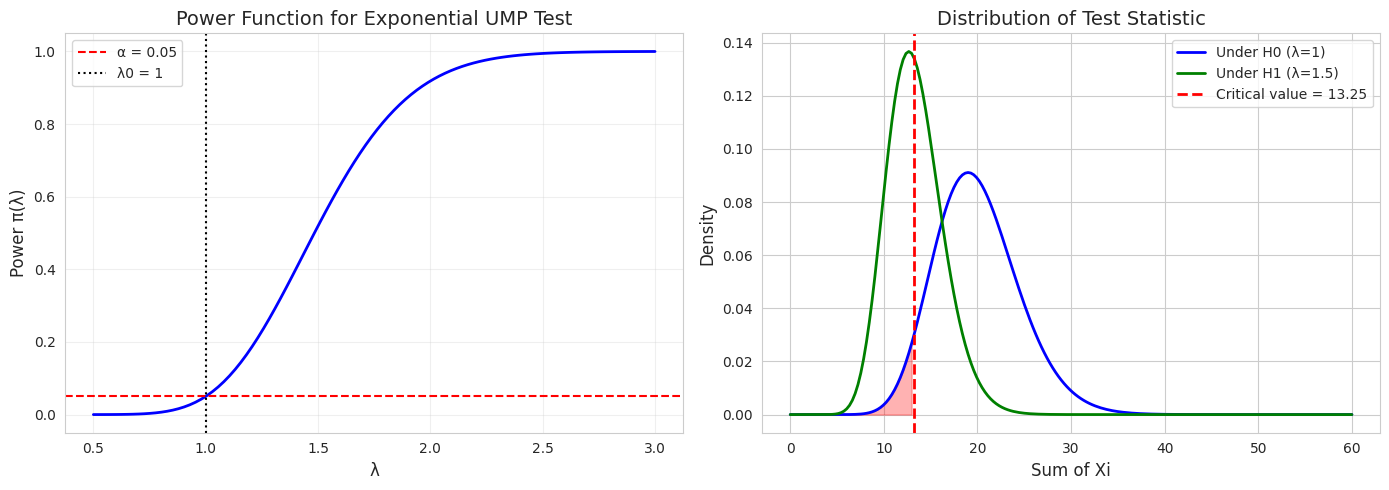

In [8]:
# UMP検定の例：指数分布
# H0: λ ≤ λ0 vs H1: λ > λ0

lambda_0 = 1
n = 20
alpha = 0.05

# Under H0: λ = λ0, sum of Xi ~ Gamma(n, 1/λ0)
# Reject H0 when sum(Xi) < c (smaller sum means larger λ)

# Critical value
c = stats.gamma.ppf(alpha, n, scale=1/lambda_0)

# Power function
lambda_range = np.linspace(0.5, 3, 100)
power = []

for lam in lambda_range:
    # P(sum(Xi) < c | λ = lam)
    p = stats.gamma.cdf(c, n, scale=1/lam)
    power.append(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power function
axes[0].plot(lambda_range, power, 'b-', linewidth=2)
axes[0].axhline(alpha, color='red', linestyle='--', label=f'α = {alpha}')
axes[0].axvline(lambda_0, color='black', linestyle=':', label=f'λ0 = {lambda_0}')
axes[0].set_xlabel('λ', fontsize=12)
axes[0].set_ylabel('Power π(λ)', fontsize=12)
axes[0].set_title('Power Function for Exponential UMP Test', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of test statistic
x = np.linspace(0, 60, 200)
axes[1].plot(x, stats.gamma.pdf(x, n, scale=1/lambda_0), 'b-', linewidth=2, label=f'Under H0 (λ={lambda_0})')
axes[1].plot(x, stats.gamma.pdf(x, n, scale=1/1.5), 'g-', linewidth=2, label=f'Under H1 (λ=1.5)')
axes[1].axvline(c, color='red', linestyle='--', linewidth=2, label=f'Critical value = {c:.2f}')
axes[1].fill_between(x[x < c], stats.gamma.pdf(x[x < c], n, scale=1/lambda_0), alpha=0.3, color='red')
axes[1].set_xlabel('Sum of Xi', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of Test Statistic', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 10.6 尤度比検定 (Likelihood Ratio Test)

### 一般化尤度比
$$\Lambda = \frac{\sup_{\theta \in \Theta_0} L(\theta)}{\sup_{\theta \in \Theta} L(\theta)}$$

### 漸近分布
$H_0$ の下で:
$$-2 \log \Lambda \xrightarrow{d} \chi^2(r)$$

ここで $r$ は帰無仮説で制約されるパラメータの数。

In [9]:
# 尤度比検定の例：正規分布の平均
# H0: μ = μ0 vs H1: μ ≠ μ0

np.random.seed(123)
n = 30
mu_0 = 0
true_mu = 0.5  # Actually under H1
sigma = 1

# Generate sample
sample = np.random.normal(true_mu, sigma, n)
x_bar = np.mean(sample)
s2 = np.var(sample, ddof=1)

# Likelihood ratio statistic
# -2 log Λ = n * (x̄ - μ0)² / s²
lr_stat = n * (x_bar - mu_0)**2 / s2

# P-value
p_value = 1 - stats.chi2.cdf(lr_stat, 1)

print("Likelihood Ratio Test for Normal Mean")
print("="*50)
print(f"H0: μ = {mu_0} vs H1: μ ≠ {mu_0}")
print(f"\nSample mean: {x_bar:.4f}")
print(f"Sample variance: {s2:.4f}")
print(f"\n-2 log Λ = {lr_stat:.4f}")
print(f"P-value = {p_value:.4f}")

# Compare with t-test
t_stat = np.sqrt(n) * (x_bar - mu_0) / np.sqrt(s2)
p_value_t = 2 * (1 - stats.t.cdf(abs(t_stat), n-1))
print(f"\nFor comparison, t-test:")
print(f"t = {t_stat:.4f}, p-value = {p_value_t:.4f}")

Likelihood Ratio Test for Normal Mean
H0: μ = 0 vs H1: μ ≠ 0

Sample mean: 0.5447
Sample variance: 1.4094

-2 log Λ = 6.3155
P-value = 0.0120

For comparison, t-test:
t = 2.5131, p-value = 0.0178


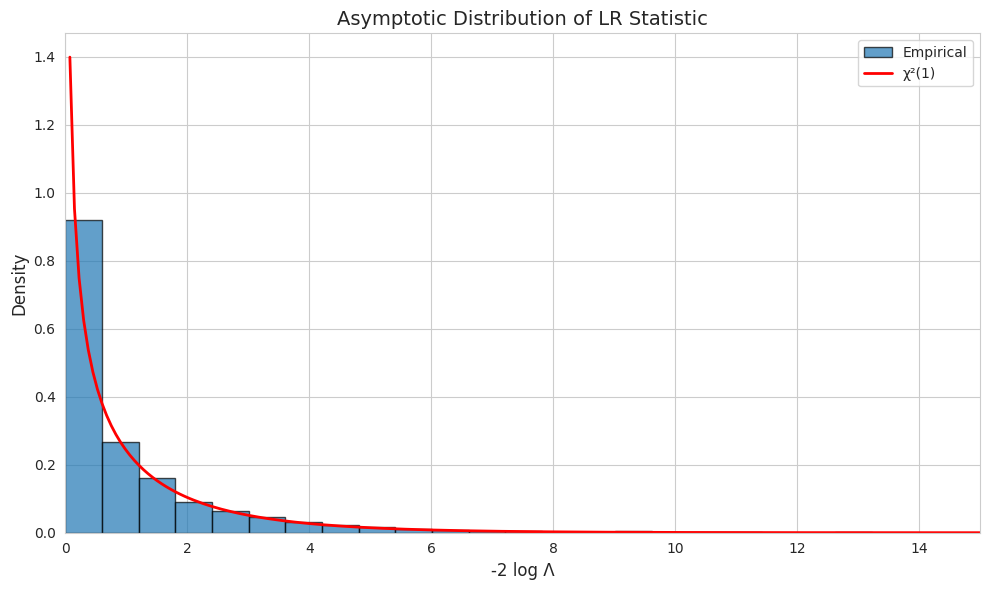

Empirical Type I error at α=0.05: 0.0609


In [10]:
# 尤度比統計量の漸近分布の検証
n_simulations = 10000
n = 30
mu_0 = 0
sigma = 1

lr_stats = []

for _ in range(n_simulations):
    sample = np.random.normal(mu_0, sigma, n)  # Under H0
    x_bar = np.mean(sample)
    s2 = np.var(sample, ddof=1)
    lr_stat = n * (x_bar - mu_0)**2 / s2
    lr_stats.append(lr_stat)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(lr_stats, bins=50, density=True, alpha=0.7, edgecolor='black', label='Empirical')
x = np.linspace(0, 15, 200)
ax.plot(x, stats.chi2.pdf(x, 1), 'r-', linewidth=2, label='χ²(1)')

ax.set_xlabel('-2 log Λ', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Asymptotic Distribution of LR Statistic', fontsize=14)
ax.legend()
ax.set_xlim(0, 15)

plt.tight_layout()
plt.show()

# Type I error rate
chi2_crit = stats.chi2.ppf(0.95, 1)
type1_error = np.mean(np.array(lr_stats) > chi2_crit)
print(f"Empirical Type I error at α=0.05: {type1_error:.4f}")

## 10.7 p値

### 定義
p値は、帰無仮説が真のとき、観測された検定統計量と同等かそれ以上に極端な値が得られる確率。

### 解釈
- $p < \alpha$ のとき $H_0$ を棄却
- p値は検定の有意水準を示す「尺度」

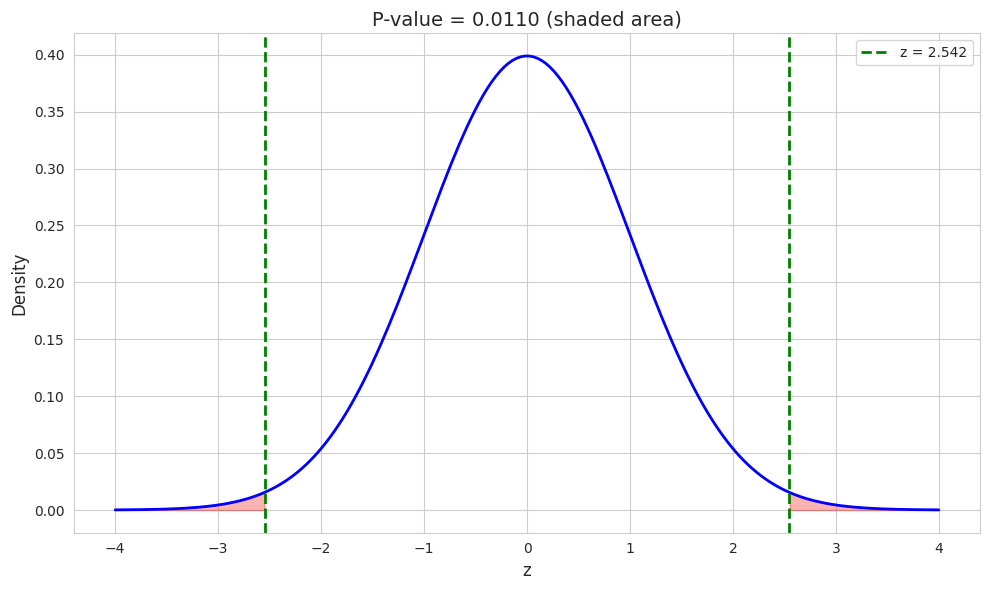

Sample mean: 105.08
z-statistic: 2.542
P-value: 0.0110

Conclusion at α=0.05: Reject H0


In [11]:
# p値の可視化
np.random.seed(456)
n = 25
mu_0 = 100
true_mu = 103
sigma = 10

sample = np.random.normal(true_mu, sigma, n)
x_bar = np.mean(sample)
se = sigma / np.sqrt(n)

# z-statistic
z = (x_bar - mu_0) / se

# p-value (two-sided)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-4, 4, 200)
ax.plot(x, stats.norm.pdf(x), 'b-', linewidth=2)

# Shade p-value regions
ax.fill_between(x[x > abs(z)], stats.norm.pdf(x[x > abs(z)]), alpha=0.3, color='red')
ax.fill_between(x[x < -abs(z)], stats.norm.pdf(x[x < -abs(z)]), alpha=0.3, color='red')

ax.axvline(z, color='green', linestyle='--', linewidth=2, label=f'z = {z:.3f}')
ax.axvline(-z, color='green', linestyle='--', linewidth=2)

ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'P-value = {p_value:.4f} (shaded area)', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Sample mean: {x_bar:.2f}")
print(f"z-statistic: {z:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"\nConclusion at α=0.05: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")

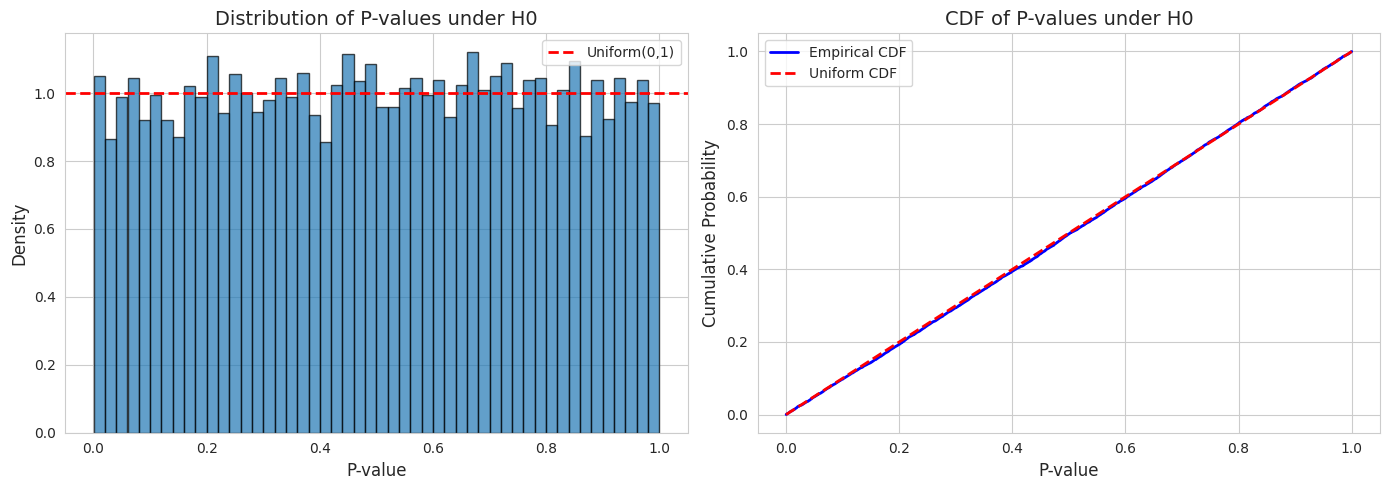

Proportion of p < 0.05 (should be ~0.05): 0.0489
Proportion of p < 0.01 (should be ~0.01): 0.0096


In [12]:
# H0が真のときのp値の分布
n_simulations = 10000
n = 30
mu_0 = 0
sigma = 1

p_values = []

for _ in range(n_simulations):
    sample = np.random.normal(mu_0, sigma, n)  # Under H0
    x_bar = np.mean(sample)
    se = sigma / np.sqrt(n)
    z = (x_bar - mu_0) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    p_values.append(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(p_values, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].axhline(1, color='red', linestyle='--', linewidth=2, label='Uniform(0,1)')
axes[0].set_xlabel('P-value', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of P-values under H0', fontsize=14)
axes[0].legend()

# Empirical CDF
p_sorted = np.sort(p_values)
ecdf = np.arange(1, len(p_sorted) + 1) / len(p_sorted)
axes[1].plot(p_sorted, ecdf, 'b-', linewidth=2, label='Empirical CDF')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Uniform CDF')
axes[1].set_xlabel('P-value', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('CDF of P-values under H0', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Proportion of p < 0.05 (should be ~0.05): {np.mean(np.array(p_values) < 0.05):.4f}")
print(f"Proportion of p < 0.01 (should be ~0.01): {np.mean(np.array(p_values) < 0.01):.4f}")

## 10.8 サンプルサイズの決定

### 公式
片側検定で検出力 $1 - \beta$ を達成するために必要なサンプルサイズ:
$$n = \frac{(z_\alpha + z_\beta)^2 \sigma^2}{(\mu_1 - \mu_0)^2}$$

Required Sample Size
α = 0.05, σ = 1

Effect Size (d) | Power=0.80 | Power=0.90 | Power=0.95
-------------------------------------------------------
      0.2       |    155     |    215     |    271    
      0.5       |     25     |     35     |     44    
      0.8       |     10     |     14     |     17    


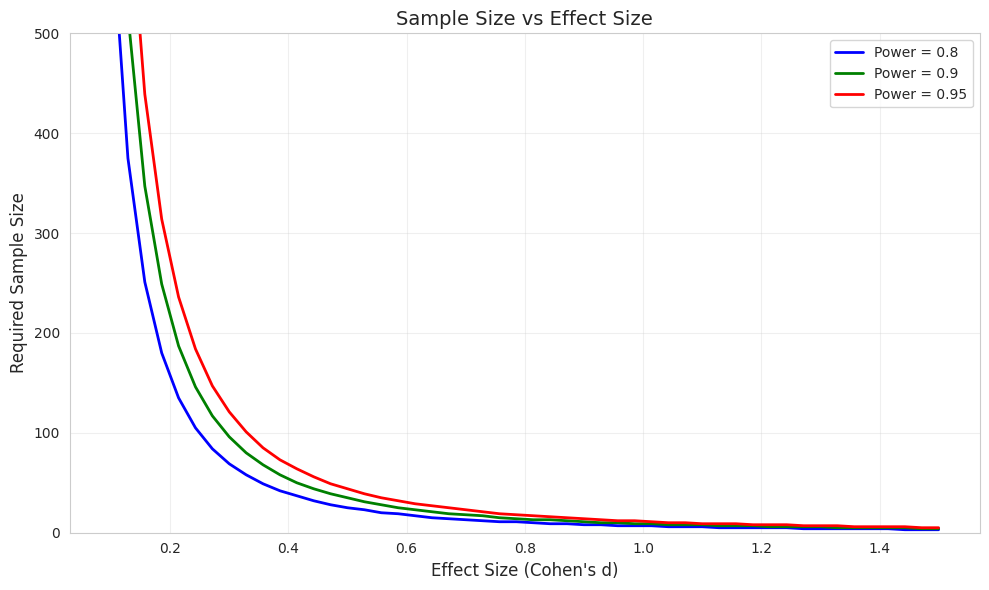

In [13]:
# サンプルサイズの計算
def calculate_sample_size(mu_0, mu_1, sigma, alpha, power):
    """Calculate required sample size for one-sided z-test."""
    z_alpha = stats.norm.ppf(1 - alpha)
    z_beta = stats.norm.ppf(power)
    n = ((z_alpha + z_beta)**2 * sigma**2) / (mu_1 - mu_0)**2
    return np.ceil(n)

# Example calculation
mu_0, mu_1 = 0, 0.5
sigma = 1
alpha = 0.05

powers = [0.80, 0.90, 0.95]
effect_sizes = [0.2, 0.5, 0.8]  # Cohen's d

print("Required Sample Size")
print("="*50)
print(f"α = {alpha}, σ = {sigma}")
print("\nEffect Size (d) | Power=0.80 | Power=0.90 | Power=0.95")
print("-"*55)

for d in effect_sizes:
    sizes = []
    for power in powers:
        n = calculate_sample_size(0, d * sigma, sigma, alpha, power)
        sizes.append(int(n))
    print(f"{d:^15} | {sizes[0]:^10} | {sizes[1]:^10} | {sizes[2]:^10}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

effect_range = np.linspace(0.1, 1.5, 50)
for power, color in zip([0.80, 0.90, 0.95], ['blue', 'green', 'red']):
    sizes = [calculate_sample_size(0, d, 1, 0.05, power) for d in effect_range]
    ax.plot(effect_range, sizes, color=color, linewidth=2, label=f'Power = {power}')

ax.set_xlabel("Effect Size (Cohen's d)", fontsize=12)
ax.set_ylabel('Required Sample Size', fontsize=12)
ax.set_title('Sample Size vs Effect Size', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 500)

plt.tight_layout()
plt.show()

## 10.9 練習問題

### 問題1
$X_1, ..., X_{16} \sim N(\mu, 4)$ のとき、$H_0: \mu = 10$ vs $H_1: \mu > 10$ の検定で、有意水準 $\alpha = 0.05$ の棄却域を求めよ。また、$\mu = 11$ のときの検出力を求めよ。

### 問題2
ベルヌーイ試行を100回行い、成功回数が60回であった。$H_0: p = 0.5$ vs $H_1: p \neq 0.5$ を有意水準5%で検定せよ。

### 問題3
$N(\mu, 1)$ からの標本で、$H_0: \mu = 0$ vs $H_1: \mu = 1$ の検定において、$\alpha = 0.05$, $\beta = 0.10$ を達成するサンプルサイズを求めよ。

In [14]:
# 問題1の解答
print("問題1: 正規分布の片側検定")
print("="*50)

n = 16
mu_0 = 10
sigma2 = 4
sigma = 2
alpha = 0.05

se = sigma / np.sqrt(n)
z_crit = stats.norm.ppf(1 - alpha)
critical_value = mu_0 + z_crit * se

print(f"\n標準誤差: σ/√n = {sigma}/{np.sqrt(n):.0f} = {se}")
print(f"z_0.05 = {z_crit:.3f}")
print(f"\n棄却域: X̄ > {critical_value:.3f}")

# Power at mu = 11
mu_1 = 11
power = 1 - stats.norm.cdf(critical_value, mu_1, se)

print(f"\nμ = {mu_1} のときの検出力: {power:.4f}")

問題1: 正規分布の片側検定

標準誤差: σ/√n = 2/4 = 0.5
z_0.05 = 1.645

棄却域: X̄ > 10.822

μ = 11 のときの検出力: 0.6388


In [15]:
# 問題2の解答
print("問題2: 母比率の検定")
print("="*50)

n = 100
x = 60
p_0 = 0.5
p_hat = x / n

# z-statistic
z = (p_hat - p_0) / np.sqrt(p_0 * (1 - p_0) / n)

# p-value (two-sided)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"\np̂ = {p_hat}")
print(f"z = ({p_hat} - {p_0}) / √({p_0} × {1-p_0} / {n})")
print(f"z = {z:.3f}")
print(f"\np値 = {p_value:.4f}")
print(f"\n結論: p値 = {p_value:.4f} {'<' if p_value < 0.05 else '>'} 0.05")
print(f"       H0を{'棄却する' if p_value < 0.05 else '棄却しない'}")

問題2: 母比率の検定

p̂ = 0.6
z = (0.6 - 0.5) / √(0.5 × 0.5 / 100)
z = 2.000

p値 = 0.0455

結論: p値 = 0.0455 < 0.05
       H0を棄却する


In [16]:
# 問題3の解答
print("問題3: サンプルサイズの決定")
print("="*50)

mu_0, mu_1 = 0, 1
sigma = 1
alpha = 0.05
beta = 0.10
power = 1 - beta

z_alpha = stats.norm.ppf(1 - alpha)
z_beta = stats.norm.ppf(power)

n = ((z_alpha + z_beta)**2 * sigma**2) / (mu_1 - mu_0)**2

print(f"\nz_α = z_0.05 = {z_alpha:.3f}")
print(f"z_β = z_0.90 = {z_beta:.3f}")
print(f"\nn = ({z_alpha:.3f} + {z_beta:.3f})² × {sigma}² / ({mu_1} - {mu_0})²")
print(f"n = {n:.2f}")
print(f"\n必要なサンプルサイズ: n = {int(np.ceil(n))}")

問題3: サンプルサイズの決定

z_α = z_0.05 = 1.645
z_β = z_0.90 = 1.282

n = (1.645 + 1.282)² × 1² / (1 - 0)²
n = 8.56

必要なサンプルサイズ: n = 9


## ⚠️ よくある間違いと解決策

### ❌ p値の誤解釈
**正しい理解:** 「p=0.03だから仮説が正しい確率97%」は誤り
**解決策:** p値は「帰無仮説が正しいとしたとき、これほど極端なデータが得られる確率」

### ❌ 有意差と実質差
**正しい理解:** 統計的に有意でも実務的に無意味な差もある
**解決策:** 効果量（Cohen's dなど）も確認する

---

## 📝 理解度チェッククイズ

### 問題 1
第1種の誤りと第2種の誤りを説明せよ

### 問題 2
p値の正しい解釈を述べよ

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---